In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from pathlib import Path
import pandas as pd
import warnings

In [3]:
plt.style.use(["science", "grid", "notebook"])
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
BASE_DIR = Path.cwd()
data_path = BASE_DIR.parents[3]/"Data"/"titanic.csv"

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

## Check Data Types

In [7]:
dtypes = df.dtypes
n_unique = df.nunique()

pd.DataFrame({"dtype": dtypes, "num_unique": n_unique})

,dtype,num_unique
Survived,int64,2
Pclass,int64,3
Sex,object,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Fare,float64,248
Cabin,object,147
Embarked,object,3


In [8]:
def check_types(df: pd.DataFrame) -> pd.DataFrame:
	dtypes = df.dtypes
	n_unique = df.nunique()

	return pd.DataFrame({"dtype": dtypes, "num_unique": n_unique})

In [9]:
cols = ["Pclass", "Survived", "Sex", "SibSp", "Parch", "Embarked"]

df[cols] = df[cols].astype("category")

In [10]:
check_types(df)

,dtype,num_unique
Survived,category,2
Pclass,category,3
Sex,category,2
Age,float64,88
SibSp,category,7
Parch,category,7
Fare,float64,248
Cabin,object,147
Embarked,category,3


## Check Null Values

In [11]:
def check_null_values(df: pd.DataFrame) -> pd.DataFrame:
	return pd.DataFrame({"no_of_nulls":df.isnull().sum().sort_values(ascending=False)})

check_null_values(df)

,no_of_nulls
Cabin,687
Age,177
Embarked,2
Survived,0
Pclass,0
SibSp,0
Sex,0
Fare,0
Parch,0


In [12]:
def calculate_null_val_percentages(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({"null_percentage":df.isnull().sum().sort_values(ascending=False) / df.shape[0]})

calculate_null_val_percentages(df)

,null_percentage
Cabin,0.771044
Age,0.198653
Embarked,0.002245
Survived,0.000000
Pclass,0.000000
SibSp,0.000000
Sex,0.000000
Fare,0.000000
Parch,0.000000


In [13]:
def replace_null_with_median(df: pd.DataFrame, column: str) -> None: 
    df[column].fillna(df[column].median(), inplace=True)

def replace_null_with_mean(df: pd.DataFrame, column: str) -> None: 
    df[column].fillna(df[column].mean(), inplace=True)

def replace_null_with_mode(df: pd.DataFrame, column: str) -> None: 
    df[column].fillna(df[column].mode(), inplace=True)

In [14]:
replace_null_with_median(df, "Age")

check_null_values(df) # age has 0 null values

,no_of_nulls
Cabin,687
Embarked,2
Survived,0
Pclass,0
Sex,0
SibSp,0
Age,0
Fare,0
Parch,0


In [15]:
# drop null values for embarked column (2 values)

df.dropna(subset="Embarked", inplace=True)

check_null_values(df)

,no_of_nulls
Cabin,687
Survived,0
Pclass,0
Age,0
Sex,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [16]:
df.drop("Cabin", axis=1, inplace=True)

check_null_values(df)

,no_of_nulls
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [17]:
def find_quartiles(df: pd.DataFrame, column: str):
	q1 = df[column].quantile(0.25)
	median = df[column].quantile(0.50)
	q3 = df[column].quantile(0.75)

	return q1, median, q3

def find_upper_lower_bounds(df: pd.DataFrame, column: str):
	q1, _, q3 = find_quartiles(df, column)
	iqr = q3 - q1

	lower_bound = q1 - (1.5 * iqr)
	upper_bound = q3 + (1.5 * iqr)

	return lower_bound, upper_bound

find_upper_lower_bounds(df, "Age")

(np.float64(2.5), np.float64(54.5))

In [18]:
numerical_cols = df.select_dtypes("number")
numerical_cols.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


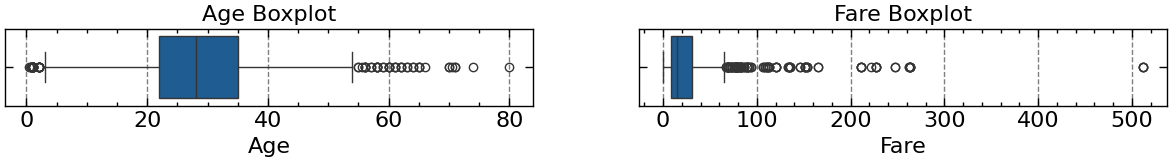

In [19]:
plt.figure(figsize=(15, 1))

for i, col in enumerate(numerical_cols):
	plt.subplot(1, 2, i+1)
	sns.boxplot(df[col], orient="h")
	plt.title(f"{col} Boxplot")

In [20]:
# removing duplacate daata
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Data Visualization

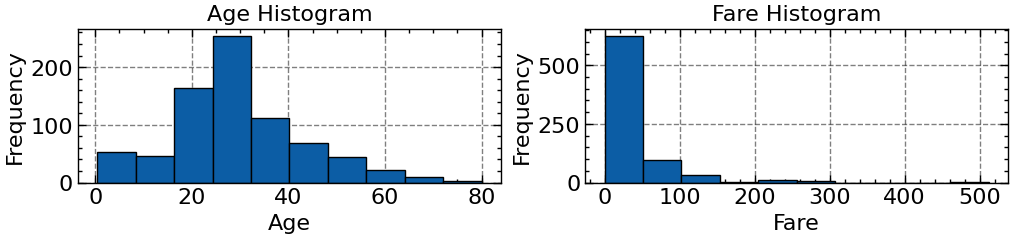

In [21]:
def visualize_histograms(df: pd.DataFrame) -> None:
	numerical_cols = df.select_dtypes("number").columns

	plt.figure(figsize=(12, 2))

	for i, column in enumerate(numerical_cols):
		plt.subplot(1, 2, i+1)
		plt.hist(df[column], edgecolor="k")
		plt.xlabel(f"{column}")
		plt.ylabel("Frequency")
		plt.title(f"{column} Histogram")

	plt.show()

def visualize_kernel_density_estimation(df: pd.DataFrame) -> None:
	numerical_cols = df.select_dtypes("number").columns

	plt.figure(figsize=(12, 2))

	for i, column in enumerate(numerical_cols):
		plt.subplot(1, 2, i+1)
		sns.kdeplot(x=df[col])
		plt.xlabel(f"{column}")
		plt.ylabel("Frequency")
		plt.title(f"{column} Histogram")

	plt.show()

visualize_histograms(df)

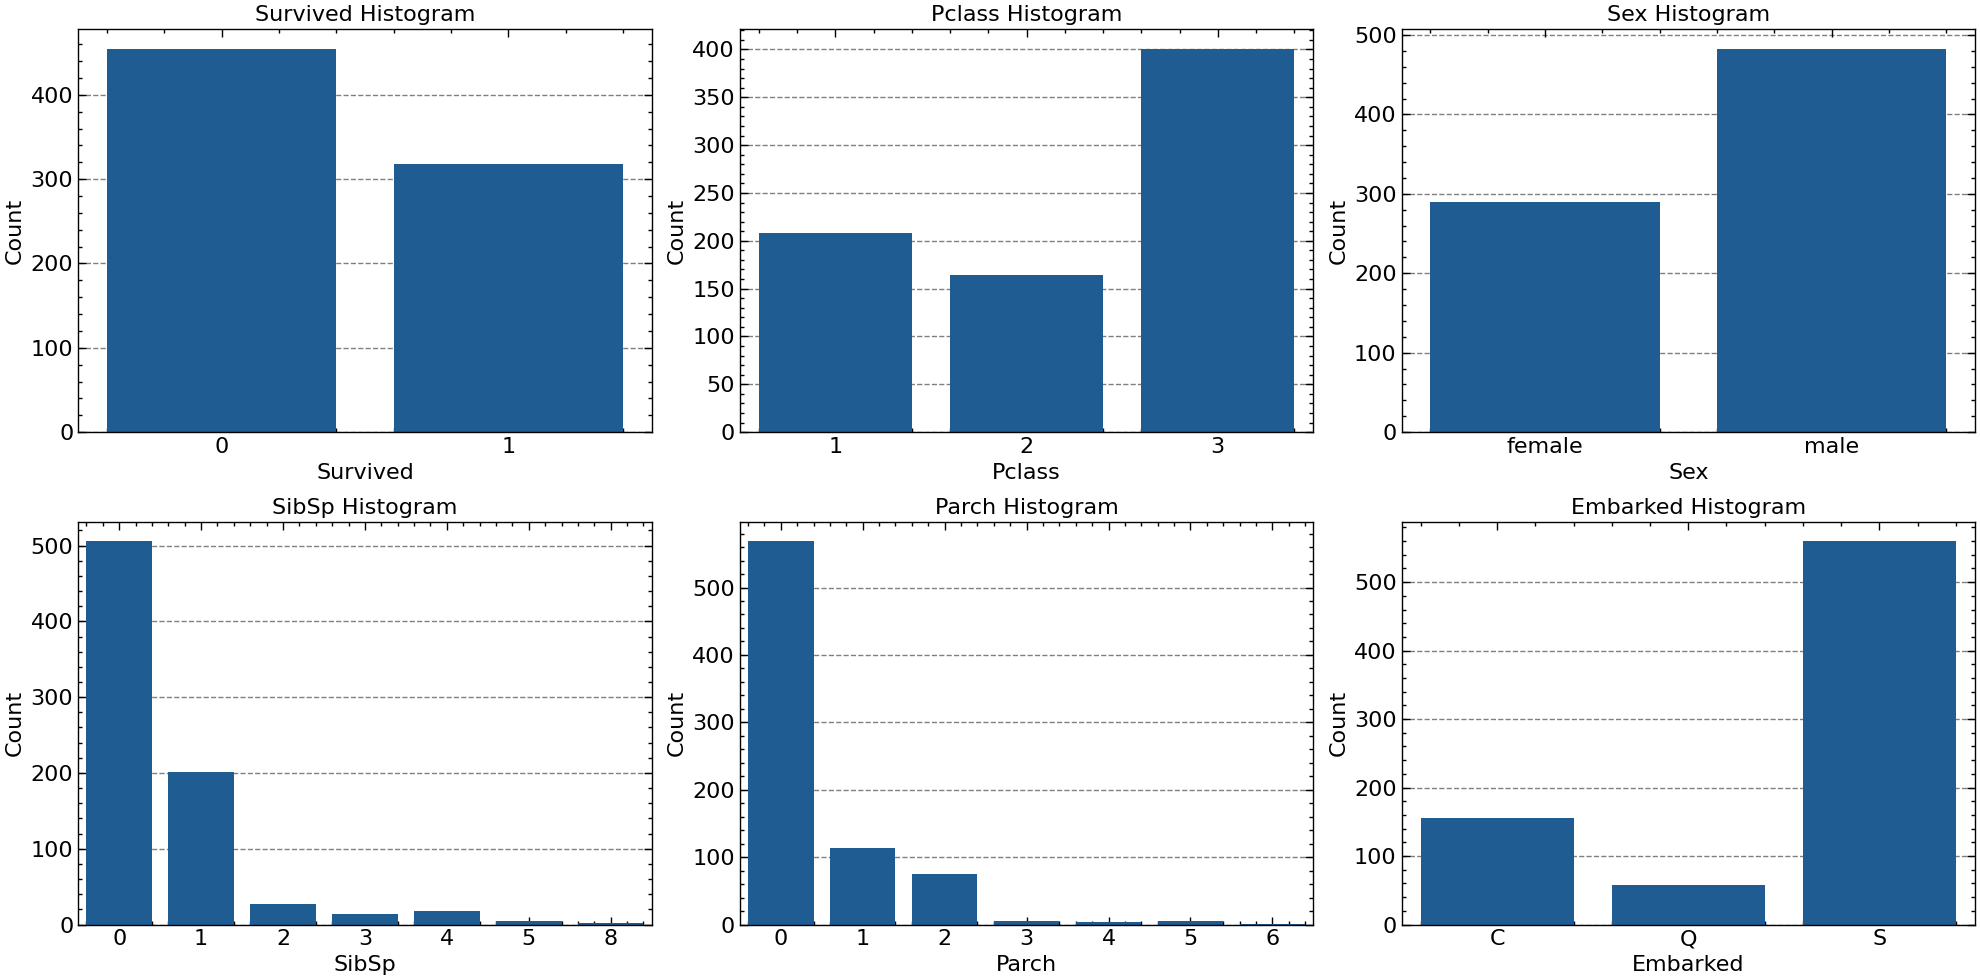

In [22]:
def visualize_categorical(df: pd.DataFrame) -> None:
	cat_cols = df.select_dtypes("category").columns

	num_cols = len(cat_cols)
	rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0) 
	
	plt.figure(figsize=(20, 5 * rows)) 
	
	for i, column in enumerate(cat_cols):
		plt.subplot(rows, 3, i+1)
		sns.countplot(x=column, data=df)
		plt.xlabel(f"{column}")
		plt.ylabel("Count")
		plt.title(f"{column} Histogram")

	plt.tight_layout()
	plt.show()
	
visualize_categorical(df)

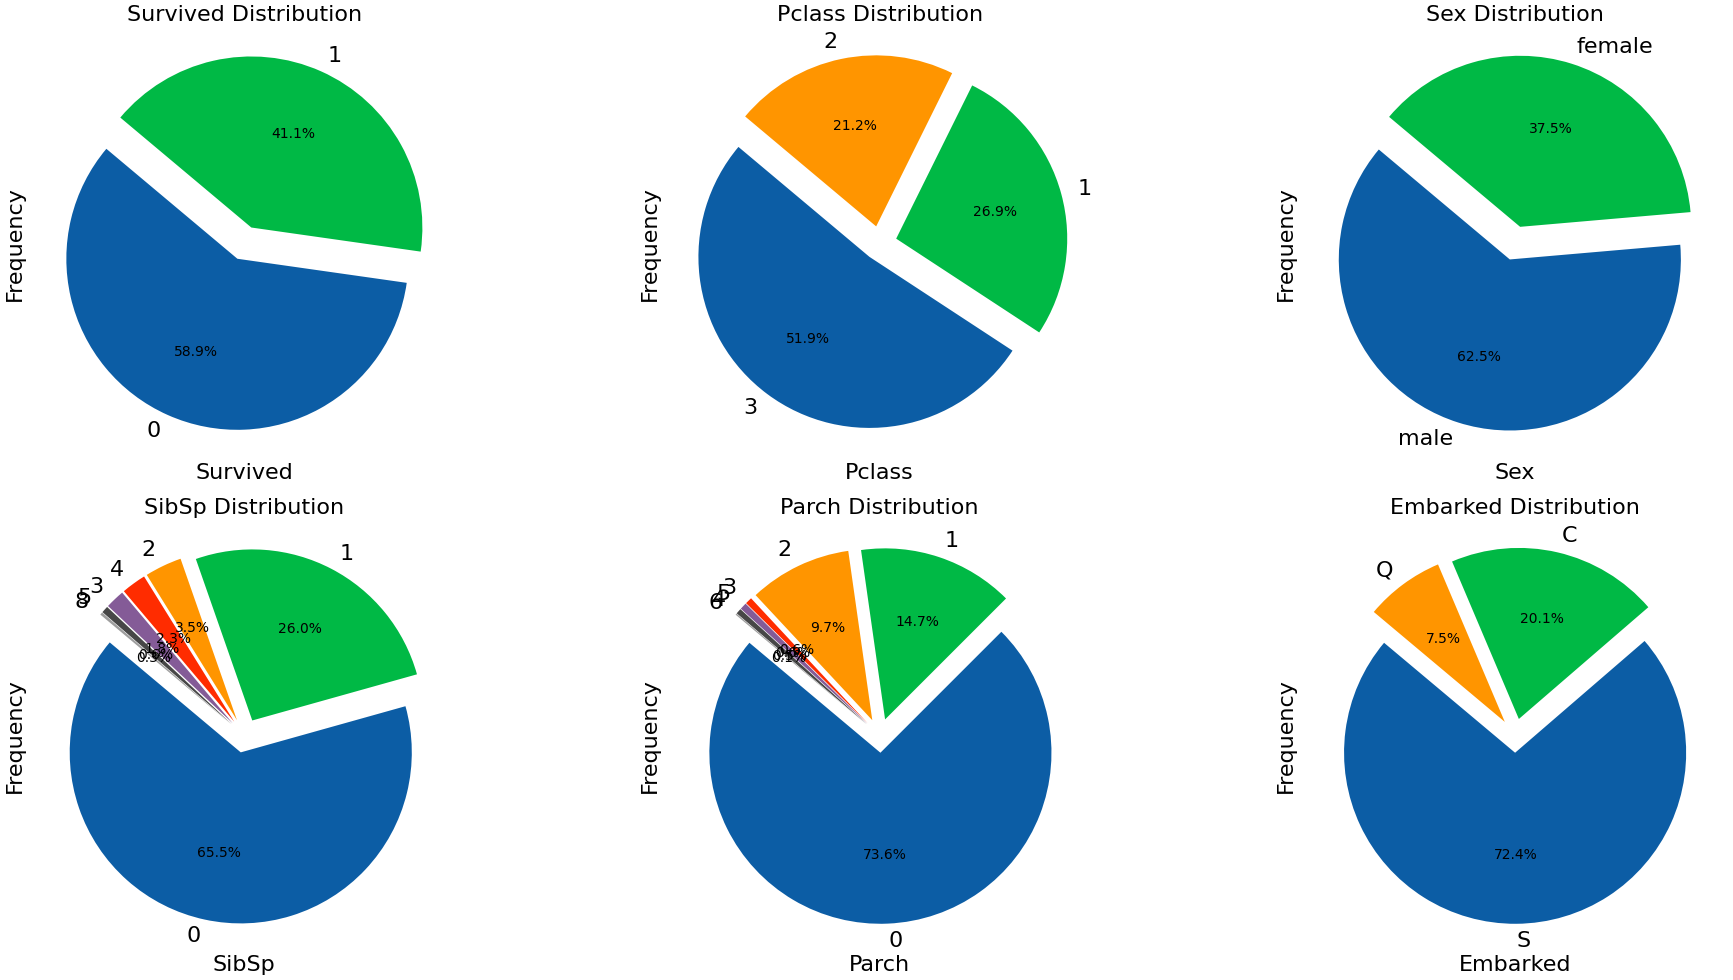

In [23]:
def visualize_categorical_v2(df: pd.DataFrame) -> None:
	cat_cols = df.select_dtypes("category").columns
	
	num_cols = len(cat_cols)
	rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0) 

	plt.figure(figsize=(20, 5 * rows)) 

	for i, column in enumerate(cat_cols):
		plt.subplot(rows, 3, i+1)
		plt.pie(df[column].value_counts(), labels=df[column].value_counts().index, startangle=140, autopct="%1.1f%%", explode = [0.1 for i in range(df[column].nunique())])
		plt.xlabel(f"{column}")
		plt.ylabel("Frequency")
		plt.title(f"{column} Distribution")

	plt.tight_layout()	
	plt.show()

visualize_categorical_v2(df)


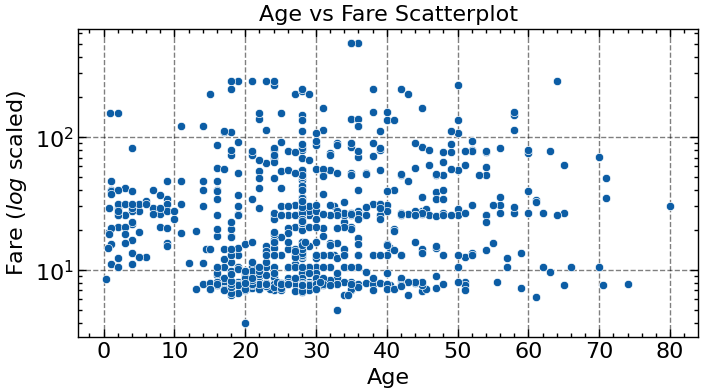

In [24]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Age", y="Fare")
plt.xlabel("Age")
plt.ylabel(r"Fare ($log$ scaled)")
plt.yscale("log")
plt.title("Age vs Fare Scatterplot")
plt.show()

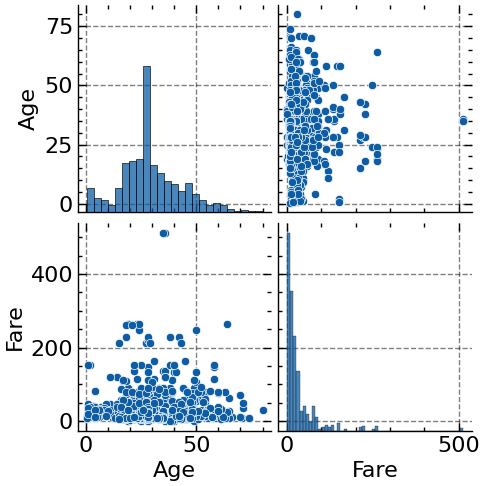

In [25]:
sns.pairplot(df)
plt.show()

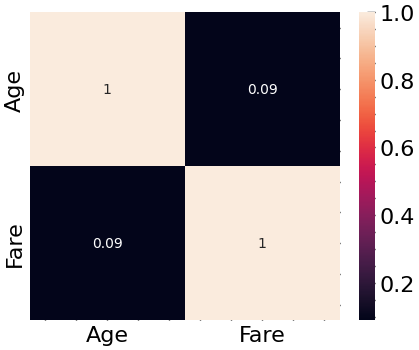

In [26]:
corr = df.select_dtypes("number").corr(method="pearson")

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True)
plt.show()

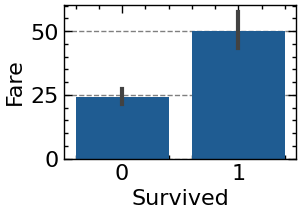

In [27]:
plt.figure(figsize=(3, 2))
sns.barplot(x="Survived", y="Fare", data=df)
plt.show()

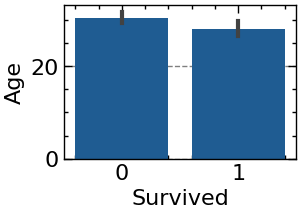

In [28]:
plt.figure(figsize=(3, 2))
sns.barplot(x="Survived", y="Age", data=df)
plt.show()

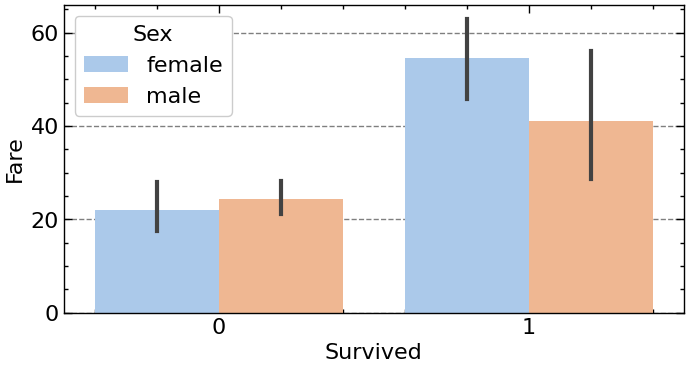

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(x="Survived", y="Fare", data=df, hue="Sex", palette="pastel")
plt.show()

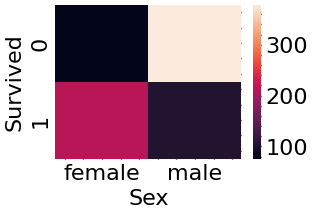

In [30]:
plt.figure(figsize=(3, 2))
agg = df.pivot_table(index="Survived", columns="Sex", values="Age", aggfunc=len)
sns.heatmap(agg)
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from category_encoders import OneHotEncoder

In [42]:
X = df.drop("Survived", axis=1)
y = df[["Survived"]]

In [47]:
scalar = MinMaxScaler()

numerical_cols = df.select_dtypes("number").columns

X[numerical_cols] = scalar.fit_transform(X[numerical_cols])

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.271174,1,0,0.014151,S
1,1,female,0.472229,1,0,0.139136,C
2,3,female,0.321438,0,0,0.015469,S
3,1,female,0.434531,1,0,0.103644,S
4,3,male,0.434531,0,0,0.015713,S


In [53]:
str_cols =  ["Sex", "Embarked"]

encoder = OneHotEncoder(cols=str_cols, drop_invariant=True)

X = encoder.fit_transform(X)

X.head()

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.271174,1,0,0.014151,1,0,0
1,1,0,1,0.472229,1,0,0.139136,0,1,0
2,3,0,1,0.321438,0,0,0.015469,1,0,0
3,1,0,1,0.434531,1,0,0.103644,1,0,0
4,3,1,0,0.434531,0,0,0.015713,1,0,0


In [4]:
BASE_DIR = Path.cwd()
data_path = BASE_DIR.parents[3]/"Data"/"insurance.csv"

In [5]:
df = pd.read_csv(data_path)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
check_types(df)

NameError: name 'check_types' is not defined

In [ ]:
from data_preprocessing import *

In [7]:
cat_cols = df.select_dtypes("object").columns
num_cols = df.select_dtypes("number").columns

In [8]:
df[cat_cols] = to_cat(df, cat_cols)

check_types(df)

NameError: name 'to_cat' is not defined

In [9]:
check_null_values(df)

NameError: name 'check_null_values' is not defined

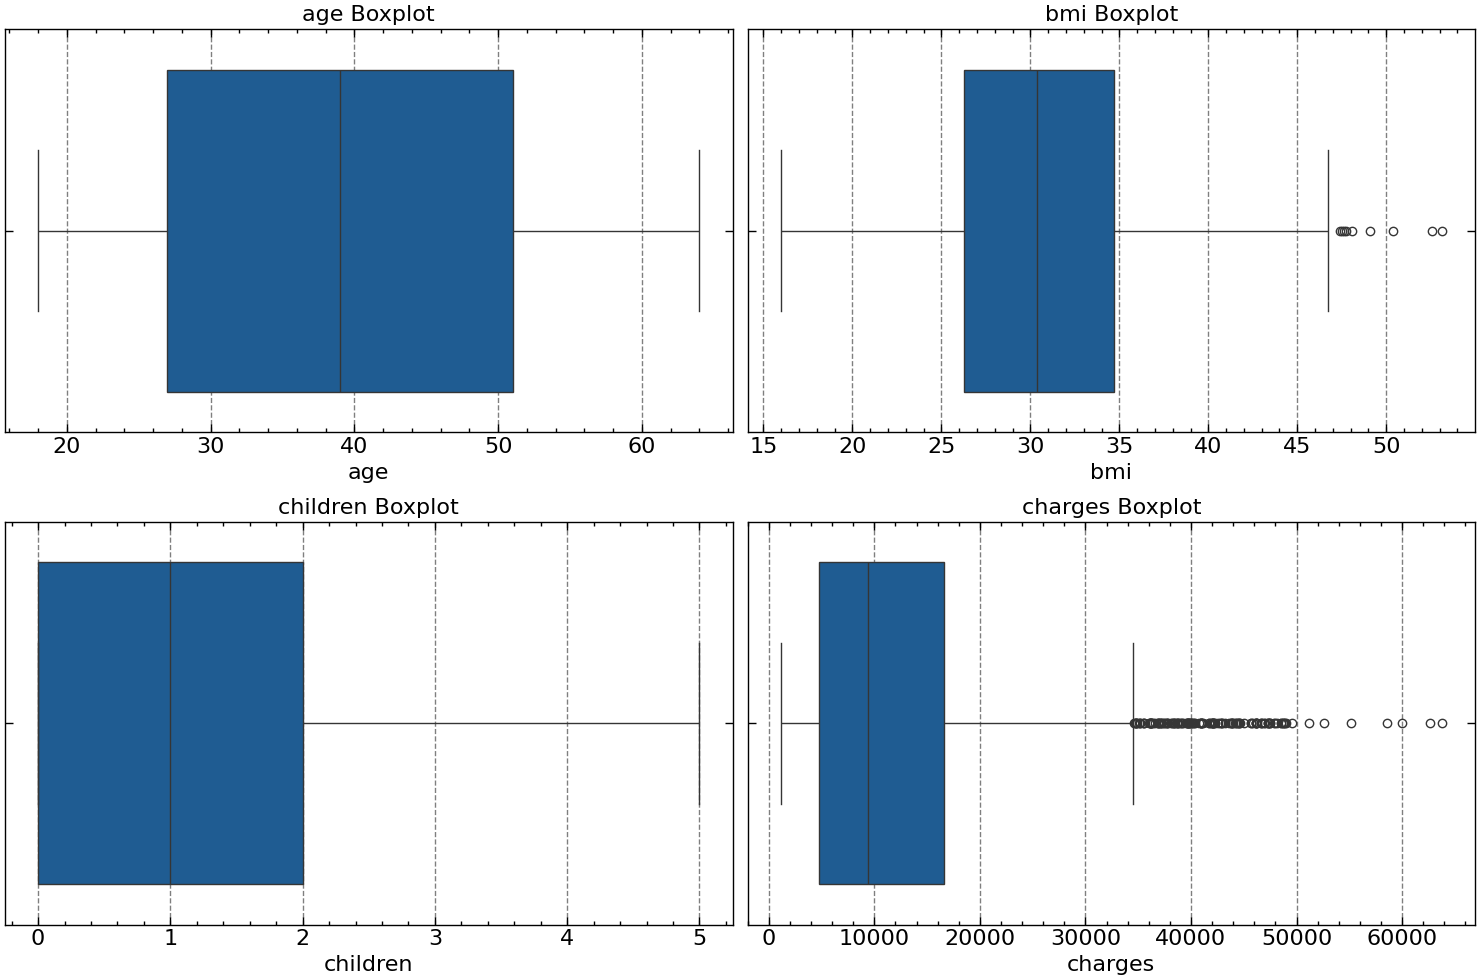

In [10]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
	plt.subplot(2, 2, i+1)
	sns.boxplot(df[col], orient="h")
	plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

In [11]:
upper, lower = find_upper_lower_bounds(df, "bmi")

print(upper)
print(lower)

NameError: name 'find_upper_lower_bounds' is not defined

In [72]:
outliers = df[df["bmi"] > upper]["bmi"].values

df["bmi"].replace(outliers, upper, inplace=True)

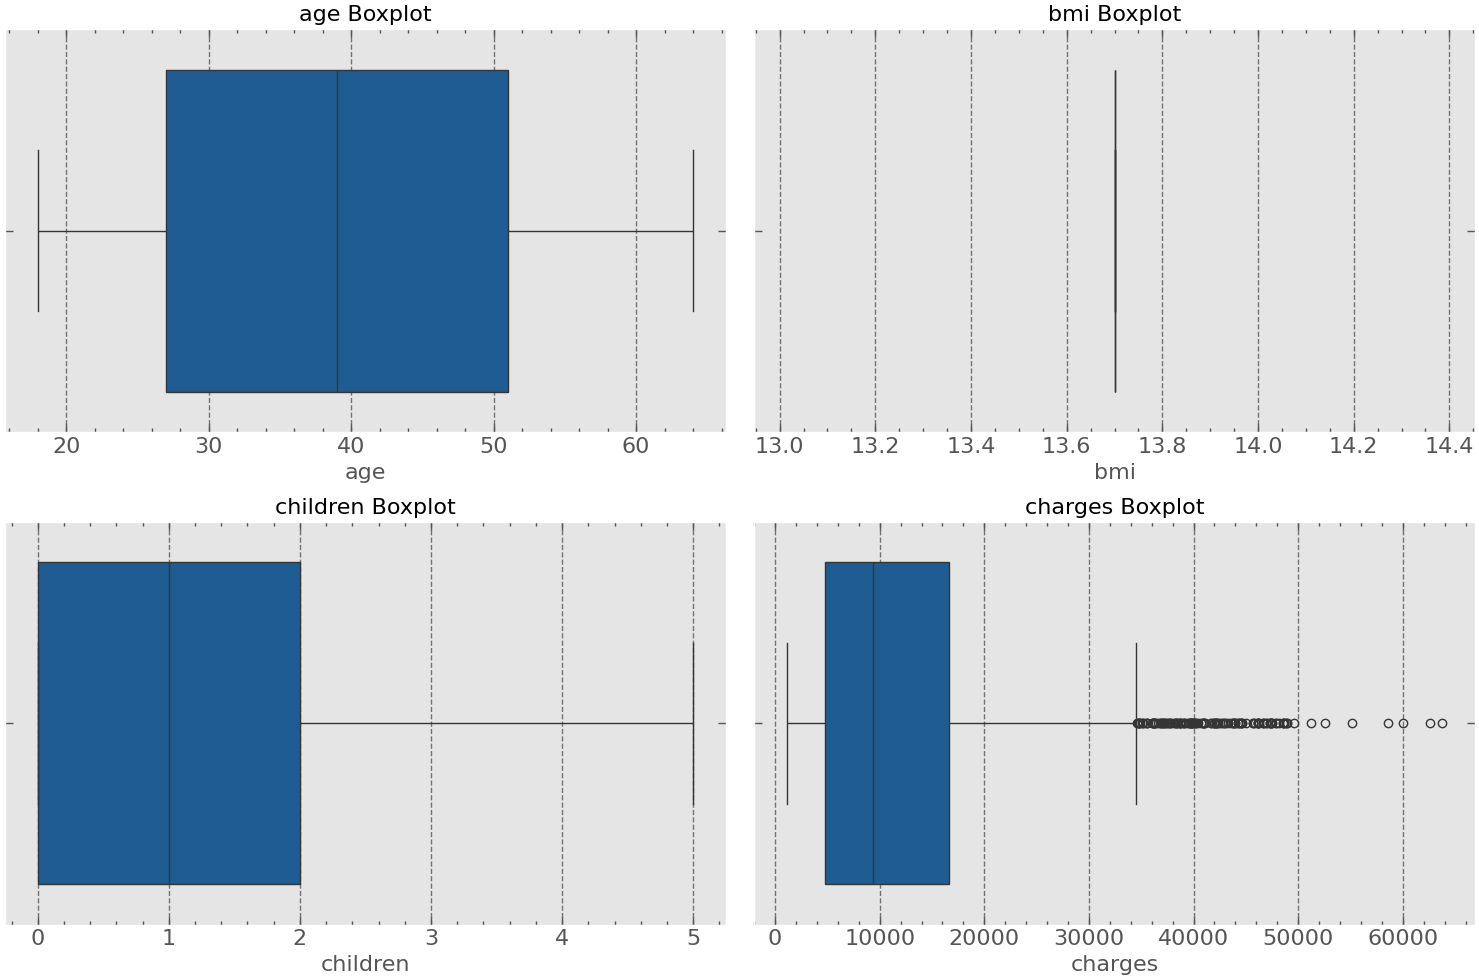

In [73]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
	plt.subplot(2, 2, i+1)
	sns.boxplot(df[col], orient="h")
	plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

In [19]:
num_cols = ["age", "bmi"]
cat_cols = ["sex", "children", "smoker", "region"]

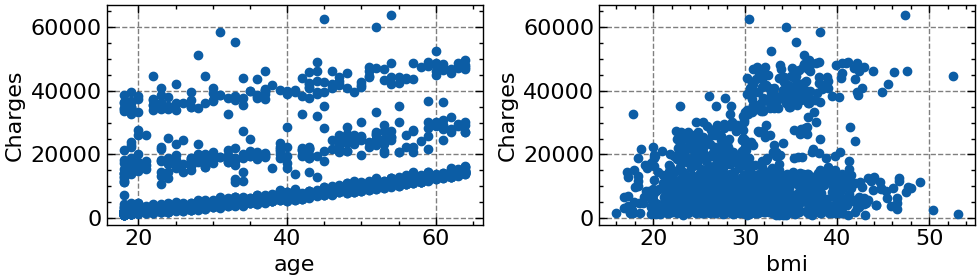

In [20]:
plt.figure(figsize=(10, 3))

for i, col in enumerate(num_cols):
	plt.subplot(1, 2, i+1)
	plt.xlabel(f"{col}")
	plt.ylabel(f"Charges")
	plt.scatter(x=df[col], y=df["charges"])

plt.tight_layout()
plt.show()

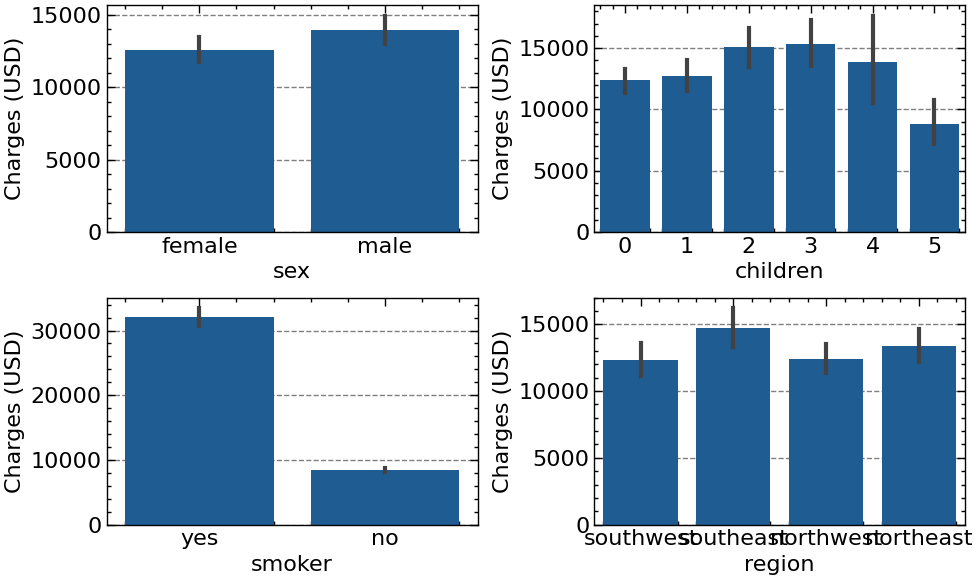

In [21]:
plt.figure(figsize=((10, 6)))

for i, col in enumerate(cat_cols):
	plt.subplot(2, 2, i+1)
	plt.xlabel(f"{col}")
	plt.ylabel("Charges (USD)")
	sns.barplot(data=df, x=col, y="charges")
plt.tight_layout()
plt.show()

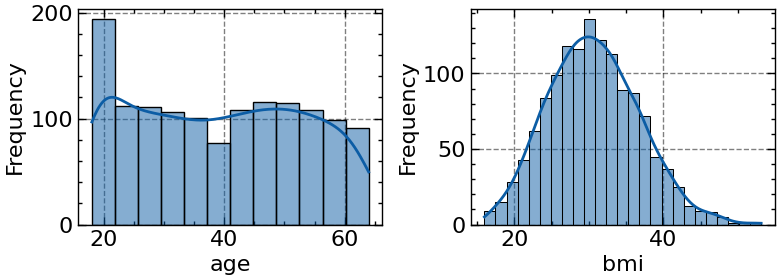

In [27]:
plt.figure(figsize=((8, 3)))

for i, col in enumerate(num_cols):
	plt.subplot(1, 2, i+1)
	plt.xlabel(f"{col}")
	plt.ylabel("Frequency")
	sns.histplot(x=col, data=df, kde=True)

plt.tight_layout()
plt.show()

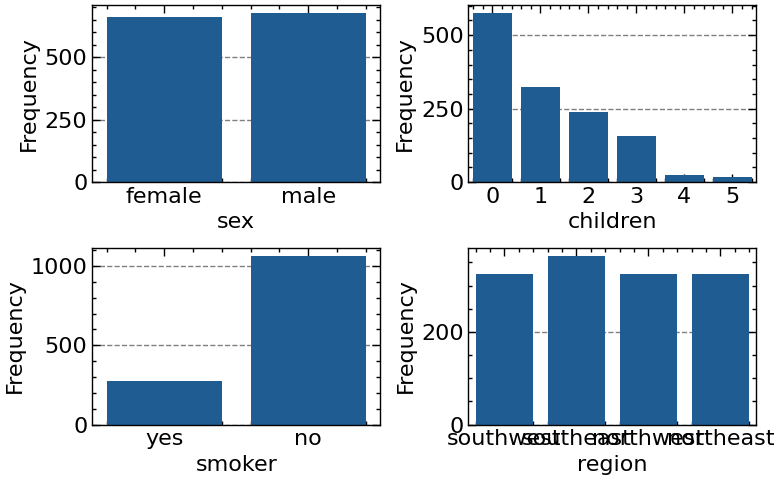

In [32]:
plt.figure(figsize=((8, 5)))

for i, col in enumerate(cat_cols):
	plt.subplot(2, 2, i+1)
	plt.xlabel(f"{col}")
	plt.ylabel("Frequency")
	sns.countplot(x=col, data=df)

plt.tight_layout()
plt.show()

In [33]:
df.duplicated().sum()
df.drop_duplicates(keep="first", inplace=True)

In [42]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1:]

In [43]:
from sklearn.preprocessing import MinMaxScaler

cols_to_norm = X.select_dtypes("number").columns

scaler = MinMaxScaler()
X[cols_to_norm] = scaler.fit_transform(X[cols_to_norm])

In [ ]:
from category_encoders import OrdinalEncoder

cols_to_encode = ['sex', 'smoker']
ordinal_encoder = OrdinalEncoder(cols=cols_to_encode)

X = ordinal_encoder.fit_transform(X)

In [46]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(cols=["region"])
X = encoder.fit_transform(X)

In [47]:
X.head()

,age,sex,bmi,children,smoker,region_1,region_2,region_3,region_4
0,0.021739,1,0.321227,0.0,1,1,0,0,0
1,0.000000,2,0.479150,0.2,2,0,1,0,0
2,0.217391,2,0.458434,0.6,2,0,1,0,0
3,0.326087,2,0.181464,0.0,2,0,0,1,0
4,0.304348,2,0.347592,0.0,2,0,0,1,0
